In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd

path = "/content/drive/MyDrive/journal_data.csv"

# Sütun isimlerini manuel olarak tanımlıyoruz çünkü CSV'de başlık satırı yok
column_names = ['AcademicRecordId', 'AbstractText', 'JournalName', 'Keywords', 'Subjects']

# names=column_names diyerek sütunları biz isimlendiriyoruz
df = pd.read_csv(path, names=column_names, header=None)

# Kontrol edelim, şimdi AbstractText gelmiş olmalı
print(df.columns)
df.head()

Index(['AcademicRecordId', 'AbstractText', 'JournalName', 'Keywords',
       'Subjects'],
      dtype='object')


,AcademicRecordId,AbstractText,JournalName,Keywords,Subjects
0,88652,<p>After using evolutionary techniques for sin...,ACM COMPUTING SURVEYS,"algorithms, artificial intelligence, genetic a...","Computer Science, Theory & Methods, Computer S..."
1,88653,<p>Distributed data processing is becoming a r...,ACM COMPUTING SURVEYS,"query optimization, query execution, client-se...","Computer Science, Theory & Methods, Computer S..."
2,88654,<p>Logical models of argument formalize common...,ACM COMPUTING SURVEYS,"defeasible argumentation, argumentative system...","Computer Science, Theory & Methods, Computer S..."
3,88655,<p>In this paper we review studies of the grow...,ACM COMPUTING SURVEYS,"theory, clustering, algorithms, indexing, info...","Computer Science, Theory & Methods, Computer S..."
4,88656,<p>We survey the current techniques to cope wi...,ACM COMPUTING SURVEYS,"edit distance, Levenshtein distance, online st...","Computer Science, Theory & Methods, Computer S..."


In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Gerekli NLP paketlerini indiriyoruz
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""
    # 1. HTML etiketlerini temizle (örn: <p>)
    text = re.sub(r'<.*?>', '', text)
    # 2. Sadece harfleri tut (sayıları ve noktalama işaretlerini kaldır)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # 3. Küçük harfe çevir ve kelimelere ayır
    words = text.lower().split()
    # 4. Stopwords'leri at ve Lemmatization uygula (kelime köküne in)
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(cleaned_words)

# Temizlenmiş sütunları oluşturuyoruz
df['clean_abstract'] = df['AbstractText'].apply(clean_text)
df['clean_keywords'] = df['Keywords'].apply(clean_text)
df['clean_subjects'] = df['Subjects'].apply(clean_text)

# Hepsini tek bir 'feature' (özellik) sütununda birleştiriyoruz
df['all_text'] = df['clean_abstract'] + " " + df['clean_keywords'] + " " + df['clean_subjects']

# Sonucu kontrol edelim
df[['JournalName', 'all_text']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,JournalName,all_text
0,ACM COMPUTING SURVEYS,using evolutionary technique single objective ...
1,ACM COMPUTING SURVEYS,distributed data processing becoming reality b...
2,ACM COMPUTING SURVEYS,logical model argument formalize commonsense r...
3,ACM COMPUTING SURVEYS,paper review study growth internet technology ...
4,ACM COMPUTING SURVEYS,survey current technique cope problem string m...


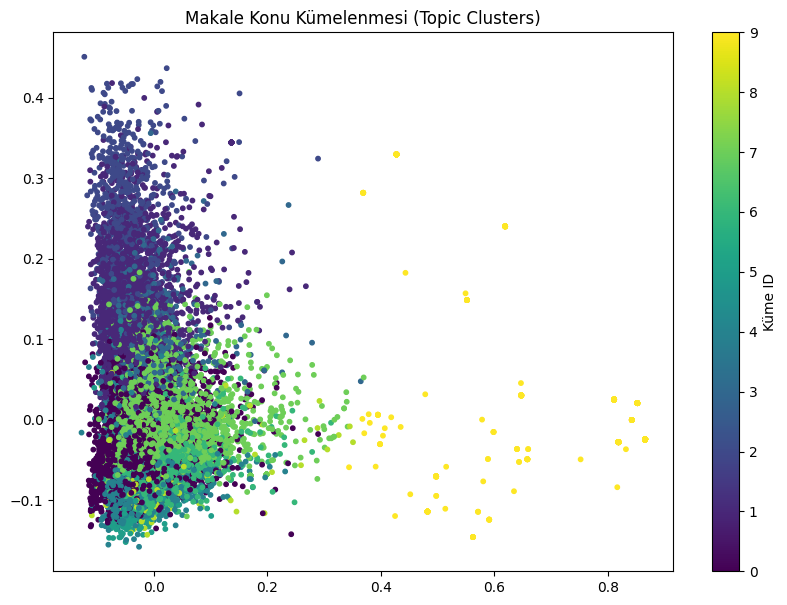

             JournalName  cluster
0  ACM COMPUTING SURVEYS        4
1  ACM COMPUTING SURVEYS        7
2  ACM COMPUTING SURVEYS        6
3  ACM COMPUTING SURVEYS        7
4  ACM COMPUTING SURVEYS        4
5  ACM COMPUTING SURVEYS        4
6  ACM COMPUTING SURVEYS        0
7  ACM COMPUTING SURVEYS        6
8  ACM COMPUTING SURVEYS        0
9  ACM COMPUTING SURVEYS        0


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Metinleri Sayısal Vektörlere Dönüştürme (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000) # En önemli 5000 kelimeyi alıyoruz
X = tfidf.fit_transform(df['all_text'])

# 2. Kümeleme (K-Means) - Ödevde istendiği gibi k=10 seçelim
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

# 3. Kümeleri Görselleştirme (PCA ile 2 boyuta indirgeyerek)
pca = PCA(n_components=2)
coords = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], c=df['cluster'], cmap='viridis', s=10)
plt.title('Makale Konu Kümelenmesi (Topic Clusters)')
plt.colorbar(label='Küme ID')
plt.show()

# Her kümeden örnekler görelim
print(df[['JournalName', 'cluster']].head(10))

In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Her dergi için ortalama bir vektör (profil) hesaplayalım
# Bu işlem, o dergide yayınlanan tüm makalelerin 'merkezini' bulur
journal_profiles = {}
unique_journals = df['JournalName'].unique()

for journal in unique_journals:
    # O dergiye ait makalelerin satır indekslerini bul
    indices = df[df['JournalName'] == journal].index
    # O indekslerdeki vektörlerin ortalamasını al
    journal_profiles[journal] = np.asarray(X[indices].mean(axis=0))

# 2. Öneri Fonksiyonu
def find_top_5_journals(user_abstract):
    # Kullanıcının metnini temizle ve vektöre dönüştür
    cleaned_input = clean_text(user_abstract)
    input_vector = tfidf.transform([cleaned_input]).toarray()

    similarities = {}
    for journal, profile_vector in journal_profiles.items():
        # Kosinüs benzerliği hesapla
        sim = cosine_similarity(input_vector, profile_vector)[0][0]
        similarities[journal] = sim

    # Benzerlik puanına göre sırala ve ilk 5'i al
    sorted_journals = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
    return sorted_journals[:5]

# --- TEST ETME ---
test_abstract = "Deep learning and neural networks are revolutionizing image processing tasks."
results = find_top_5_journals(test_abstract)

print("--- Önerilen İlk 5 Dergi ---")
for i, (journal, score) in enumerate(results, 1):
    print(f"{i}. {journal} (Benzerlik Puanı: {score:.4f})")

--- Önerilen İlk 5 Dergi ---
1. NEURAL PROCESSING LETTERS (Benzerlik Puanı: 0.3650)
2. NEUROCOMPUTING (Benzerlik Puanı: 0.3628)
3. NEURAL NETWORKS (Benzerlik Puanı: 0.2923)
4. NEURAL NETWORK WORLD (Benzerlik Puanı: 0.2556)
5. IEEE TRANSACTIONS ON NEURAL NETWORKS AND LEARNING SYSTEMS (Benzerlik Puanı: 0.2427)
